#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Nicolas Bravo

En este trabajo se va a analizar cómo afecta el ventaneo a la estimación de la amplitud y frecuencia de una senoidal con ruido. La frecuencia de las senoidales realizadas varia aleatoriamente entre ±2 bins de la frecuencia nominal (250 Hz). Se va a comparar como afectan las ventanas: rectangular, flat-top, Blackman-Harris y Hann.

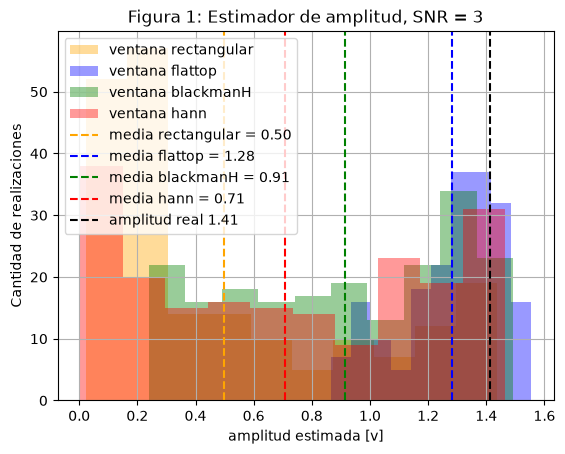

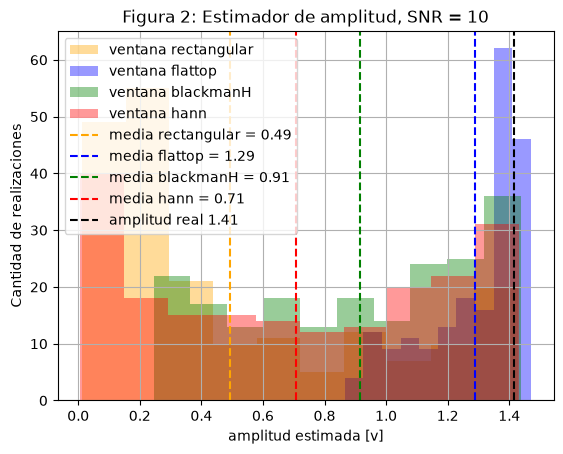

Estimador de amplitud con SNR = 3
                  |   s_a   |   v_a   |
----------------------------------------
| Rectangular     | -0.916  |  0.197  |
| Flat-top        | -0.133  |  0.029  |
| Blackman-Harris | -0.502  |  0.144  |
| Hann            | -0.707  |  0.235  |


Estimador de amplitud con SNR = 10
                  |   s_a   |   v_a   |
----------------------------------------
| Rectangular     | -0.920  |  0.197  |
| Flat-top        | -0.127  |  0.025  |
| Blackman-Harris | -0.499  |  0.140  |
| Hann            | -0.708  |  0.232  |


In [1]:
# -- coding: utf-8 --
"""
Created on Wed Sep  9 19:22:59 2026

@author: Usuario
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import flattop, blackmanharris, hann

# Parámetros base
fs = 1000
N = 1000
M = 200
a0 = np.sqrt(2)  # Potencia de 1W: (a0^2)/2 = 1
Omega0 = np.pi / 2
k0 = N // 4      # Bin correspondiente a Omega0 (pi/2)
SNR = np.arange(2)
SNR[0] = 3
SNR[1] = 10

#%%funcion seno
def mi_funcion_sen( fr, na, N = N, M = M):
    n = np.arange(N)
    Omega1 = Omega0 + fr * 2 * np.pi / N
    Omega1 = Omega1.reshape((1, M))
    n = n.reshape((N, 1))
    Omex = Omega1 * n
    xx = a0 * np.sin(Omex) + na
    return xx


def estimadores(senal, ventana,N = N, fs = fs):
    xx = senal * ventana.reshape((N, 1))
    XX = np.fft.fft(xx, axis = 0)
    XX =np.abs(XX)
    frec = np.arange(start=0, step=fs, stop=fs*N)/N
    frec = frec.reshape((N, 1))
    est_amp = 2 * XX[k0, :] / np.sum(ventana)
    est_frec = np.argmax(XX[:N//2, :], axis = 0)
    return (est_amp, est_frec)

#%%ventanas 
rect = np.ones(N)
flat = flattop(N)
BKMh = blackmanharris(N)
hann = hann(N)
#%%
sigma = np.sqrt((10 ** (-SNR[0] / 10)))
fr = np.random.uniform(-2, 2, M)
na1 = sigma * np.random.randn(N, M)
sigma = np.sqrt((10 ** (-SNR[1] / 10)))
na2 = sigma * np.random.randn(N, M)
xx = mi_funcion_sen(na = na1, fr = fr)
xx2 = mi_funcion_sen(na = na2, fr = fr)

est_ampR, est_frecR = estimadores(xx, rect) 
est_ampF, est_frecF = estimadores(xx, flat)
est_ampB, est_frecB = estimadores(xx, BKMh)
est_ampH, est_frecH = estimadores(xx, hann)

rect_media = np.mean(est_ampR)
flat_media = np.mean(est_ampF)
blackm_media = np.mean(est_ampB)
hann_media = np.mean(est_ampH)

est2_ampR, est2_frecR = estimadores(xx2, rect) 
est2_ampF, est2_frecF = estimadores(xx2, flat)
est2_ampB, est2_frecB = estimadores(xx2, BKMh)
est2_ampH, est2_frecH = estimadores(xx2, hann)

rect_media2 = np.mean(est2_ampR)
flat_media2 = np.mean(est2_ampF)
blackm_media2 = np.mean(est2_ampB)
hann_media2 = np.mean(est2_ampH)

#%% SNR = 3 xx
plt.figure()
plt.title('Figura 1: Estimador de amplitud, SNR = 3')
plt.xlabel('amplitud estimada [v]')
plt.ylabel('Cantidad de realizaciones')
plt.hist(est_ampR, alpha = 0.4, label = 'ventana rectangular', bins = 10, color = 'orange')
plt.hist(est_ampF, alpha = 0.4, label = 'ventana flattop', bins = 10, color = 'blue')
plt.hist(est_ampB, alpha = 0.4, label = 'ventana blackmanH', bins = 10, color = 'green')
plt.hist(est_ampH, alpha = 0.4, label = 'ventana hann', bins = 10, color = 'red')

plt.axvline(rect_media, linestyle = '--', color = 'orange', label = f'media rectangular = {rect_media:.2f}')
plt.axvline(flat_media, linestyle = '--', color = 'blue', label = f'media flattop = {flat_media:.2f}')
plt.axvline(blackm_media, linestyle = '--', color = 'green', label = f'media blackmanH = {blackm_media:.2f}')
plt.axvline(hann_media, linestyle = '--', color = 'red', label = f'media hann = {hann_media:.2f}')
plt.axvline(a0, linestyle = '--', color = 'black', label = f'amplitud real {a0:.2f}')
plt.grid()
plt.legend(loc = 'upper left')
plt.show()
#%% SNR = 10 xx2
plt.figure()
plt.title('Figura 2: Estimador de amplitud, SNR = 10')
plt.xlabel('amplitud estimada [v]')
plt.ylabel('Cantidad de realizaciones')
plt.hist(est2_ampR, alpha = 0.4, label = 'ventana rectangular', bins = 10, color = 'orange')
plt.hist(est2_ampF, alpha = 0.4, label = 'ventana flattop', bins = 10, color = 'blue')
plt.hist(est2_ampB, alpha = 0.4, label = 'ventana blackmanH', bins = 10, color = 'green')
plt.hist(est2_ampH, alpha = 0.4, label = 'ventana hann', bins = 10, color = 'red')

plt.axvline(rect_media2, linestyle = '--', color = 'orange', label = f'media rectangular = {rect_media2:.2f}')
plt.axvline(flat_media2, linestyle = '--', color = 'blue', label = f'media flattop = {flat_media2:.2f}')
plt.axvline(blackm_media2, linestyle = '--', color = 'green', label = f'media blackmanH = {blackm_media2:.2f}')
plt.axvline(hann_media2, linestyle = '--', color = 'red', label = f'media hann = {hann_media2:.2f}')
plt.axvline(a0, linestyle = '--', color = 'black', label = f'amplitud real {a0:.2f}')
plt.grid()
plt.legend(loc = 'upper left');
plt.show()
print("Estimador de amplitud con SNR = 3")
print(f'  {"":<{15}} | {"s_a":^{7}} | {"v_a":^{7}} |')
print('-'*40)
print(f'| {"Rectangular":<{15}} | {-a0+rect_media:^{7}.3f} | {np.var(est_ampR):^{7}.3f} |')
print(f'| {"Flat-top":<{15}} | {-a0+flat_media:^{7}.3f} | {np.var(est_ampF):^{7}.3f} |')
print(f'| {"Blackman-Harris":<{15}} | {-a0+blackm_media:^{7}.3f} | {np.var(est_ampB):^{7}.3f} |')
print(f'| {"Hann":<{15}} | {-a0+hann_media:^{7}.3f} | {np.var(est_ampH):^{7}.3f} |')
print("\n")
print("Estimador de amplitud con SNR = 10")
print(f'  {"":<{15}} | {"s_a":^{7}} | {"v_a":^{7}} |')
print('-'*40)
print(f'| {"Rectangular":<{15}} | {-a0+rect_media2:^{7}.3f} | {np.var(est2_ampR):^{7}.3f} |')
print(f'| {"Flat-top":<{15}} | {-a0+flat_media2:^{7}.3f} | {np.var(est2_ampF):^{7}.3f} |')
print(f'| {"Blackman-Harris":<{15}} | {-a0+blackm_media2:^{7}.3f} | {np.var(est2_ampB):^{7}.3f} |')
print(f'| {"Hann":<{15}} | {-a0+hann_media2:^{7}.3f} | {np.var(est2_ampH):^{7}.3f} |')

Analizando los estimadores de amplitud, prácticamente ni el sesgo ni la varianza cambian al tener dos SNR distintos, la causa de la pequeña diferencia que existe es culpa del corrimiento de las frecuencias en las 200 realizaciones.
Analizando solo la Figura 1 se puede ver cómo afecta cada tipo de ventana al estimador, las ventanas con un lóbulo principal más fino presentan mayor varianza y su media esta más alejada del valor real de amplitud. Esto se debe a que, al ser más fino, capta menos picos en su lóbulo principal y los demás los toma en los lóbulos secundarios. al medir el valor de amplitud en una frecuencia fija (N/4 250Hz) es poco probable que haya un pico de amplitud y es más posible que haya un valor menor.

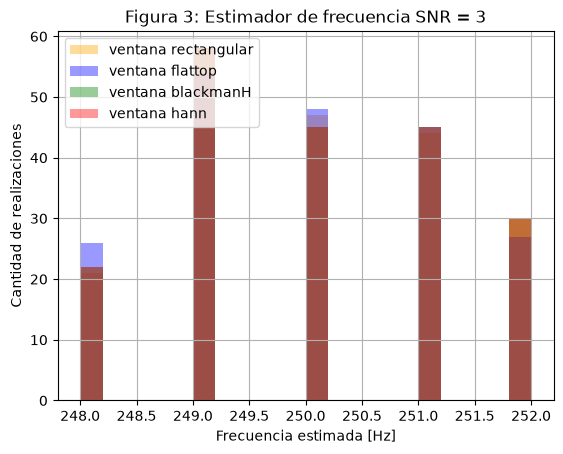

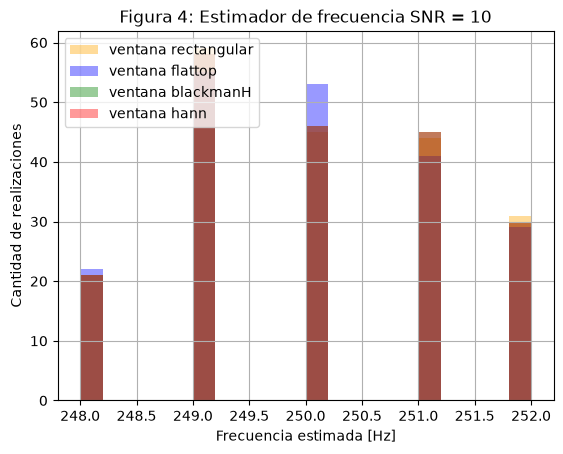

Estimador de frecuencia con SNR = 3
                  |   s_a   |   v_a   |
----------------------------------------
| Rectangular     |  0.02   |  0.08   |
| Flat-top        |  -0.04  |  0.17   |
| Blackman-Harris |  0.01   |  0.08   |
| hann            |  0.01   |  0.08   |
Estimador de frecuencia con SNR = 10
                  |   s_a   |   v_a   |
----------------------------------------
| Rectangular     |  0.02   |  0.08   |
| Flat-top        |  -0.00  |  0.12   |
| Blackman-Harris |  0.02   |  0.08   |
| hann            |  0.02   |  0.08   |


In [2]:
plt.figure()
plt.title("Figura 3: Estimador de frecuencia SNR = 3")
plt.xlabel("Frecuencia estimada [Hz]")
plt.ylabel("Cantidad de realizaciones")
plt.hist(est_frecR, alpha = 0.4, label = 'ventana rectangular', bins = 20, color = 'orange')
plt.hist(est_frecF, alpha = 0.4, label = 'ventana flattop', bins = 20, color = 'blue')
plt.hist(est_frecB, alpha = 0.4, label = 'ventana blackmanH', bins = 20, color = 'green')
plt.hist(est_frecH, alpha = 0.4, label = 'ventana hann', bins = 20, color = 'red')
plt.grid()
plt.legend(loc = 'upper left')
plt.show()
plt.figure()
plt.title("Figura 4: Estimador de frecuencia SNR = 10")
plt.xlabel("Frecuencia estimada [Hz]")
plt.ylabel("Cantidad de realizaciones")
plt.hist(est2_frecR, alpha = 0.4, label = 'ventana rectangular', bins = 20, color = 'orange')
plt.hist(est2_frecF, alpha = 0.4, label = 'ventana flattop', bins = 20, color = 'blue')
plt.hist(est2_frecB, alpha = 0.4, label = 'ventana blackmanH', bins = 20, color = 'green')
plt.hist(est2_frecH, alpha = 0.4, label = 'ventana hann', bins = 20, color = 'red')
plt.grid()
plt.legend(loc = 'upper left');
plt.show()

rect_mediafrec = np.mean(est_frecR)
flat_mediafrec = np.mean(est_frecF)
blackm_mediafrec = np.mean(est_frecB)
hannw_mediafrec = np.mean(est_frecH)

rect_mediafrec2 = np.mean(est2_frecR)
flat_mediafrec2 = np.mean(est2_frecF)
blackm_mediafrec2 = np.mean(est2_frecB)
hannw_mediafrec2 = np.mean(est2_frecH)

print("Estimador de frecuencia con SNR = 3")
print(f'  {"":<{15}} | {"s_a":^{7}} | {"v_a":^{7}} |')
print('-'*40)
print(f'| {"Rectangular":<{15}} | {-k0 + rect_mediafrec - np.mean(fr):^{7}.2f} | {np.var(est_frecR-k0-fr):^{7}.2f} |')
print(f'| {"Flat-top":<{15}} | {-k0 + flat_mediafrec - np.mean(fr):^{7}.2f} | {np.var(est_frecF-k0-fr):^{7}.2f} |')
print(f'| {"Blackman-Harris":<{15}} | {-k0 + blackm_mediafrec - np.mean(fr):^{7}.2f} | {np.var(est_frecB-k0-fr):^{7}.2f} |')
print(f'| {"hann":<{15}} | {-k0 + hannw_mediafrec - np.mean(fr):^{7}.2f} | {np.var(est_frecH-k0-fr):^{7}.2f} |')

print("Estimador de frecuencia con SNR = 10")
print(f'  {"":<{15}} | {"s_a":^{7}} | {"v_a":^{7}} |')
print('-'*40)
print(f'| {"Rectangular":<{15}} | {-k0 + rect_mediafrec2 - np.mean(fr):^{7}.2f} | {np.var(est2_frecR-k0-fr):^{7}.2f} |')
print(f'| {"Flat-top":<{15}} | {-k0 + flat_mediafrec2 - np.mean(fr):^{7}.2f} | {np.var(est2_frecF-k0-fr):^{7}.2f} |')
print(f'| {"Blackman-Harris":<{15}} | {-k0 + blackm_mediafrec2 - np.mean(fr):^{7}.2f} | {np.var(est2_frecB-k0-fr):^{7}.2f} |')
print(f'| {"hann":<{15}} | {-k0 + hannw_mediafrec2 - np.mean(fr):^{7}.2f} | {np.var(est2_frecH-k0-fr):^{7}.2f} |')

Se puede ver que el sesgo del estimador de frecuencia es prácticamente cero y se puede ver que la varianza de la ventana "Flat-top" es mayor comparada con la de las demás ventanas. Esto es debido a que en el lóbulo principal de la "Flat-top" los espectros se aplanan y puede hacer que el ruido afecte y desplace el máximo a un bin cercano.

## Conclusión

Al estimar la amplitud y la frecuencia se pudo ver cómo afecta cada tipo de ventana. En el estimador de amplitud se pudo apreciar como la "Flat-top" es la mejor opción para analizar señales con frecuencias cercanas a la frecuencia de referencia ya que posee la menor varianza pero esto no siempre es así ya que, si la frecuencia de la señal entra en un bin entero, la mejor opción es utilizar una ventana rectangular ya que esta se anula en los bins enteros fuera del principal haciendo que toda la energía de la señal quede solo en un bin.
En el estimador de frecuencia se vio como la ventana "Flat-top" es la que más varianza tiene dando una menor precisión al valor real de la señal.